In [1]:
import os
os.environ["DDE_BACKEND"] = "tensorflow"
os.environ["CUDA_VISIBLE_DEVICES"] = ""


In [2]:
import deepxde as dde
#dde.config.set_default_autodiff("zcs")
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

2026-08-24 02:35:33.776778: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-24 02:35:33.932358: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-24 02:35:33.932879: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-24 02:35:33.970775: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-24 02:35:34.033796: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-24 02:35:34.034211: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [51]:
spatial_geom = dde.geometry.Rectangle([0.0, 0.0], [1.0, 1.0])
timedomain = dde.geometry.TimeDomain(0.0, 1.0)
geom = dde.geometry.GeometryXTime(spatial_geom, timedomain)

THE nu in the equation can either be a trainable parameter and be passed as a dde.Variable or it can be a variable parameter set during inference(part of the inputs).

In [52]:
pho = 1

In [53]:
def Navier_stokes(x, y, z): #x[1] is the trunk inputs, x[0] is the branch inputs(x is a nested list of both branch and trunk inputs)
    trunk_coords = x
    branch_coords = x[0]

    u = y[:, 0:1]
    v = y[:, 1:2]
    p = y[:, 2:3]

    nu = 0.1

    #continuity equation
    du_dx = dde.grad.jacobian(u, trunk_coords, i=0, j=0)
    dv_dy = dde.grad.jacobian(v, trunk_coords, i=0, j=1)

    #x-momentum equation
    du_dt = dde.grad.jacobian(u, trunk_coords, i=0, j=2)
    du_dy = dde.grad.jacobian(u, trunk_coords, i=0, j=1)
    dp_dx = dde.grad.jacobian(p, trunk_coords, i=0, j=0)
    du_xx = dde.grad.hessian(u, trunk_coords, component=0, i=0, j=0)
    du_yy = dde.grad.hessian(u, trunk_coords, component=0, i=1, j=1)
    x_mom = du_dt + u*du_dx + v*du_dy + (1/pho)*dp_dx - nu*(du_xx + du_yy)

    #y-momentum equation
    dv_dt = dde.grad.jacobian(v, trunk_coords, i=0, j=2)
    dv_dy = dde.grad.jacobian(v, trunk_coords, i=0, j=1)
    dp_dy = dde.grad.jacobian(p, trunk_coords, i=0, j=1)
    dv_xx = dde.grad.hessian(v, trunk_coords, component=0, i=0, j=0)
    dv_yy = dde.grad.hessian(v, trunk_coords, component=0, i=1, j=1)
    dv_dx = dde.grad.jacobian(v, trunk_coords, i=0, j=0)
    y_mom = dv_dt + u*dv_dx + v*dv_dy + (1/pho)*dp_dy - nu*(dv_xx + dv_yy)

    return [x_mom, y_mom]

#enforce the stream function using an output_transform


In [54]:
#Enforicing the stream function psi here to satisfy the continuity automatically

def output_transform(inputs, outputs):
    trunk_inputs = inputs[1]
    x = trunk_inputs[:, 0:1]
    y = trunk_inputs[:, 1:2]
    t = trunk_inputs[:, 2:3]

    psi = outputs[:, 0:1]
    p = outputs[:, 1:2]

    psi = x * (1 - x) * y * (1 - y) * psi #hard boundary(enforcing 0.0 output at x = 0.0, y=0.0)

    u = dde.grad.jacobian(psi, trunk_inputs, i=0, j=1)
    v = - dde.grad.jacobian(psi, trunk_inputs, i=0, j=0)

    return tf.concat([u, v, p], axis=1)


In [55]:
def is_on_right_boundary(X, on_boundary):
    if not on_boundary:
        return False

    return dde.utils.isclose(X[0], 1.0)

def pressure_outlet(X):
    return 0.0


def is_on_wall(X, on_boundary):
    if not on_boundary:
        return False

    return dde.utils.isclose(X[1], 0.0) or dde.utils.isclose(X[1], 1.0)

def wall_condition(X):
    return 0.0

In [56]:
#Initial condition
def is_initial(X, is_initial):
    if not is_initial:
        return False

    return dde.utils.isclose(X[2], 0.0)

def initial_value(X):
    return 0.0

In [57]:
bc_p_out = dde.icbc.DirichletBC(geom, pressure_outlet, is_on_right_boundary, component=2)
bc_u = dde.icbc.DirichletBC(geom, wall_condition, is_on_wall, component=0)
bc_v = dde.icbc.DirichletBC(geom, wall_condition, is_on_wall, component=1)
ic_u = dde.icbc.IC(geom, initial_value, is_initial, component=0)
ic_v = dde.icbc.IC(geom, initial_value, is_initial, component=1)
ic_p = dde.icbc.IC(geom, initial_value, is_initial, component=2)

In [68]:
#Added a boundary condition for Pin as well
def left_boundary(X, on_boundary):
    if not on_boundary:
        return False

    return dde.utils.isclose(X[0], 0.0)

def Pin_value(X, aux_value):
    return aux_value

bc_p_in = dde.icbc.DirichletBC(geom, Pin_value, left_boundary, component=2)

In [96]:
data = dde.data.TimePDE(
    geom,
    Navier_stokes,
    [bc_u, bc_v, bc_p_out, bc_p_in],
    num_domain=2000,
    num_boundary=100,
    num_test=1000,
    train_distribution="pseudo"
)

DEFINING THE OPERATOR AND FUNCTION SPACE

In [79]:
class ConstantFuncSpace(dde.data.function_spaces.FunctionSpace):
    def __init__(self, low, high):
        self.low = low
        self.high = high

    def random(self, size):
        return np.random.uniform(self.low, self.high, size=(size, 1))

    def eval_one(self, feature, x):
        return feature[0]

    def eval_batch(self, features, xs):
        return np.tile(features, (1, len(xs)))

In [80]:
#Defining the function space
func_space = ConstantFuncSpace(low=0.5, high=2.0)

n_sensors = 1

eval_points = np.linspace(0, 1.0, n_sensors)[:, None]


In [97]:
pde_op = dde.data.PDEOperator(
    pde=data,
    function_space=func_space,
    evaluation_points=eval_points,
    num_function=1,
    num_test=1000,
    function_variables=[0],
)

In [98]:
#Model definition
n_sensors = 1

net = dde.nn.DeepONet(
    [n_sensors]+[64]*2, # n_sensors + pin, l and d(dimensions of the pipe)
    [3]+[64]*2,
    "tanh",
    "Glorot normal",
    num_outputs=2,
    multi_output_strategy="split_both"
)
net.apply_output_transform(output_transform)

In [99]:
model = dde.Model(pde_op, net)

model.compile("adam", lr=0.001)

Compiling model...
'compile' took 0.002880 s



In [84]:
early_stop = dde.callbacks.EarlyStopping(patience=5)
out_dir = "pino_models"
os.makedirs(out_dir, exist_ok=True)
ckpt = dde.callbacks.ModelCheckpoint(out_dir)

In [85]:
resampler = dde.callbacks.PDEPointResampler(period=1000)

In [ ]:
losshistory, train_state = model.train(iterations=15000, disregard_previous_best=True,
                                       display_every=1000)
dir = "pino_01"
os.makedirs(dir, exist_ok=True)
dde.saveplot(losshistory, train_state, issave=True, isplot=True, output_dir=dir)

Training model...



/media/srimukha-sarma/Windows-SSD/conda-envs/deepxde/lib/python3.11/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(
2026-08-24 04:16:34.531006: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 294950400 exceeds 10% of free system memory.
2026-08-24 04:16:34.663737: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 294950400 exceeds 10% of free system memory.
2026-08-24 04:16:34.917939: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 294950400 exceeds 10% of free system memory.
2026-08-24 04:16:49.738885: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 294950400 exceed

Compiling model...
'compile' took 0.032384 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
15000     [9.98e-02, 1.09e-02, 1.34e-01, 0.00e+00, 8.69e-02, 1.10e-01]    [1.18e-01, 1.13e-02, 1.34e-01, 0.00e+00, 8.69e-02, 1.10e-01]    []  
15005     [1.00e-01, 1.09e-02, 1.34e-01, 0.00e+00, 8.81e-02, 1.08e-01]    [1.18e-01, 1.15e-02, 1.34e-01, 0.00e+00, 8.81e-02, 1.08e-01]    []  

Best model at step 15005:
  train loss: 4.41e-01
  test loss: 4.60e-01
  test metric: []

'train' took 7.431668 s

Saving loss history to pino_01_finetuned/loss.dat ...
Error: The network has multiple inputs, and saving such result han't been implemented.
Error: The network has multiple inputs, and plotting such result han't been implemented.


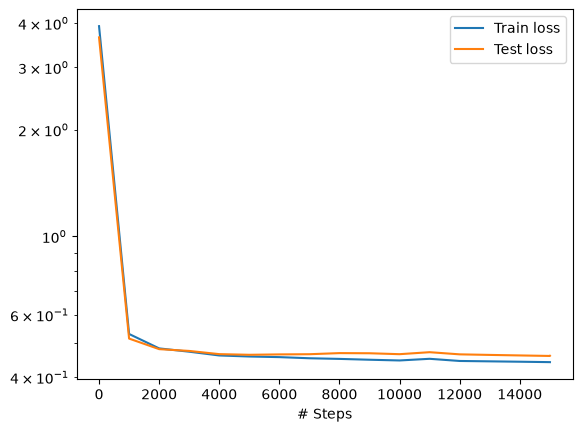

In [87]:
dde.optimizers.config.set_LBFGS_options(maxiter=30000)
model.compile("L-BFGS")
losshistory, train_state = model.train(callbacks=[early_stop, ckpt], disregard_previous_best=True, display_every=1000)

dir = "pino_01_finetuned"
os.makedirs(dir, exist_ok=True)
dde.saveplot(losshistory, train_state, issave=True, isplot=True, output_dir=dir)

In [88]:
output_dir = "pino_models_tf"
os.makedirs(output_dir, exist_ok=True)
model.save(os.path.join(output_dir, "pino_01"), protocol="backend", verbose=0)

'pino_models_tf/pino_01-15005.weights.h5'

EVAL

In [89]:
test_x = np.random.uniform(0.0, 1.0, (1000, 1))
test_y = np.random.uniform(0.0, 1.0, (1000, 1))
test_t = np.random.uniform(0.0, 1.0, (1000, 1))
test_xyt_trunk = np.hstack([test_x, test_y, test_t])

n_sensors = 1
branch_func = np.random.uniform(0.0, 1.0, (1, n_sensors))
branch_net = np.tile(branch_func, (1000, 1))




residuals = model.predict((branch_net, test_xyt_trunk))

print(f"X_mom: {residuals[0]}")
print(f"Y_mom: {residuals[1]}")


X_mom: [ 0.04937476 -0.03612837  0.89653134]
Y_mom: [ 0.026427   -0.02756796  0.29153   ]


In [90]:
#checking outputs on random points

test_pts = np.array([
    [0.05, 0.5, 0.5], [0.15, 0.5, 0.5], [0.20, 0.5, 0.5], [0.25, 0.5, 0.5], [0.30, 0.5, 0.5], [0.35, 0.5, 0.5], [0.45, 0.5, 0.5],
    [0.55, 0.5, 0.5], [0.65, 0.5, 0.5], [0.75, 0.5, 0.5], [0.85, 0.5, 0.5], [0.95, 0.5, 0.5]
])

n_sensors = 1
branch_func = np.random.uniform(0.0, 1.0, (1, n_sensors))
branch_net = np.tile(branch_func, (len(test_pts), 1))

# Evaluate the PDE operator
outputs = model.predict((branch_net,test_pts))
sum_u_vel = 0
sum_v_vel = 0
sum_p = 0
for output in outputs:
    print(f"u vel: {output[0]}, v vel: {output[1]}, pressure: {output[2]}")
    sum_u_vel += output[0]
    sum_v_vel += output[1]
    sum_p += output[2]



mean_u_vel_centre = sum_u_vel / len(test_pts)
mean_v_vel_centre = sum_v_vel / len(test_pts)
mean_p_centre = sum_p / len(test_pts)
print(mean_u_vel_centre, mean_v_vel_centre, mean_p_centre)

u vel: 0.007505819201469421, v vel: 0.07997503131628036, pressure: 0.6063394546508789
u vel: 0.031626224517822266, v vel: 0.046915989369153976, pressure: 0.5919780135154724
u vel: 0.04395698010921478, v vel: 0.033770784735679626, pressure: 0.5747801065444946
u vel: 0.05480557680130005, v vel: 0.022572621703147888, pressure: 0.5530408024787903
u vel: 0.0636046975851059, v vel: 0.013200825080275536, pressure: 0.5282593965530396
u vel: 0.070113405585289, v vel: 0.005442831665277481, pressure: 0.5017173886299133
u vel: 0.07617561519145966, v vel: -0.0064687058329582214, pressure: 0.44711101055145264
u vel: 0.07372474670410156, v vel: -0.015440121293067932, pressure: 0.3941863179206848
u vel: 0.06435737013816833, v vel: -0.022765688598155975, pressure: 0.3450623154640198
u vel: 0.049907028675079346, v vel: -0.029355483129620552, pressure: 0.3011000454425812
u vel: 0.031875208020210266, v vel: -0.03655971959233284, pressure: 0.2643249034881592
u vel: 0.011179167777299881, v vel: -0.045775137

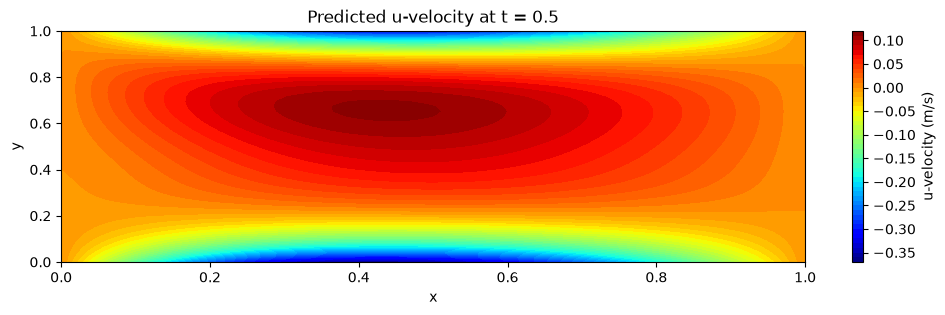

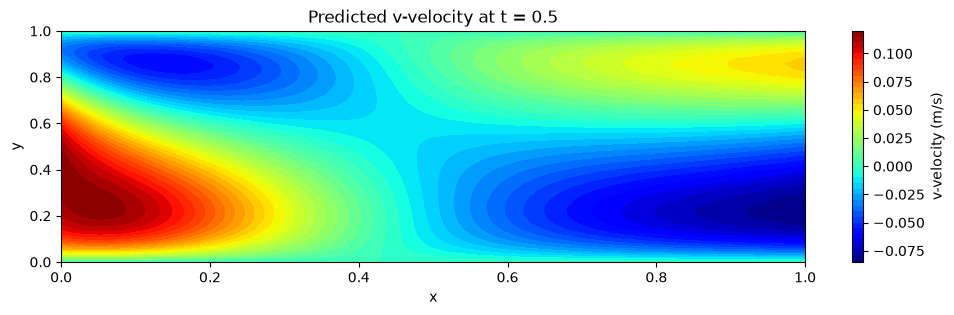

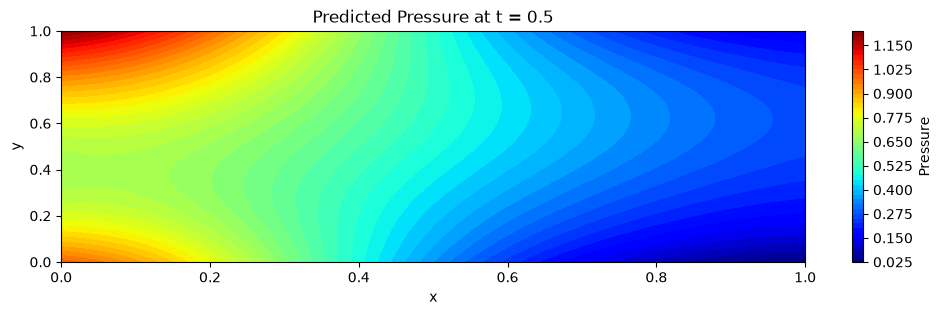

In [95]:
#Plotting the fluid flow
n_sensors = 1
branch_func = np.random.uniform(0.0, 1.0, (1, n_sensors))
branch_net = np.tile(branch_func, (10000, 1))

x_grid = np.linspace(0.0, 1.0, 200)
y_grid = np.linspace(0.0, 1.0, 50)

X, Y = np.meshgrid(x_grid, y_grid)

T = np.full_like(X, 0.5)


grid_xyt = np.vstack((X.flatten(), Y.flatten(), T.flatten())).T
pred_grid = model.predict((branch_net ,grid_xyt))

U_pred = pred_grid[:, 0].reshape(X.shape)
V_pred = pred_grid[:, 1].reshape(X.shape)
P_pred = pred_grid[:, 2].reshape(X.shape)

# 4. Plot U-Velocity Heatmap
plt.figure(figsize=(12, 3))
plt.contourf(X, Y, U_pred, levels=50, cmap='jet')
plt.colorbar(label='u-velocity (m/s)')
plt.title('Predicted u-velocity at t = 0.5')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# 5. Plot V-Velocity Heatmap
plt.figure(figsize=(12, 3))
plt.contourf(X, Y, V_pred, levels=50, cmap='jet')
plt.colorbar(label='v-velocity (m/s)')
plt.title('Predicted v-velocity at t = 0.5')
plt.xlabel('x')
plt.ylabel('y')
plt.show() 

# 6. Plot Pressure Heatmap
plt.figure(figsize=(12, 3))
plt.contourf(X, Y, P_pred, levels=50, cmap='jet')
plt.colorbar(label='Pressure')
plt.title('Predicted Pressure at t = 0.5')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

